<a href="https://colab.research.google.com/github/RutherfordOtu12/Application-of-GeoAI-A-Comparative-Methodical-urban-mapping-/blob/main/WorkFlow_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Install required packages
!pip install rasterio geopandas shapely scikit-learn numpy pandas matplotlib seaborn gdal

print("✓ All packages installed!")

✓ All packages installed!


In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import shutil
from datetime import datetime

# Geospatial libraries
import rasterio
from rasterio.transform import rowcol
import geopandas as gpd
from shapely.geometry import box

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [5]:
# Verify ZIP integrity
import zipfile

zip_path = '/content/drive/My Drive/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE.zip'  # Update with your filename

# Find ZIP file
import glob
zip_files = glob.glob(zip_path)
if not zip_files:
    print("ERROR: ZIP file not found!")
else:
    zip_path = zip_files[0]
    print(f"Found ZIP: {zip_path}")

    # Test integrity
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        print(f"✓ ZIP contains {len(file_list)} files")

        # Show first 10 files
        print("\nFirst 10 files:")
        for f in file_list[:10]:
            print(f"  {f}")

Found ZIP: /content/drive/My Drive/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE.zip
✓ ZIP contains 95 files

First 10 files:
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/MTD_DS.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/FORMAT_CORRECTNESS.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/GENERAL_QUALITY.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/GEOMETRIC_QUALITY.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/RADIOMETRIC_QUALITY.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/

In [7]:
# Create working directories
base_dir = '/content/drive/My Drive/WorkflowB'
os.makedirs(base_dir, exist_ok=True)

# Create subdirectories
dirs = {
    'raw_data': f'{base_dir}/raw_data',
    'converted_tif': f'{base_dir}/converted_tif',
    'resampled_data': f'{base_dir}/resampled_data',
    'clipped_data': f'{base_dir}/clipped_data',
    'spectral_features': f'{base_dir}/spectral_features',
    'training_data': f'{base_dir}/training_data',
    'models': f'{base_dir}/models',
    'results': f'{base_dir}/results'
}

for dir_name, dir_path in dirs.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"✓ Created: {dir_name}")

print(f"\n✓ Project structure created at: {base_dir}")

✓ Created: raw_data
✓ Created: converted_tif
✓ Created: resampled_data
✓ Created: clipped_data
✓ Created: spectral_features
✓ Created: training_data
✓ Created: models
✓ Created: results

✓ Project structure created at: /content/drive/My Drive/WorkflowB


In [8]:
# Extract ZIP to raw_data
print(f"Extracting {zip_path}...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dirs['raw_data'])

print("✓ ZIP extracted!")

# List extracted contents
extracted_folders = os.listdir(dirs['raw_data'])
print(f"\nExtracted folders: {extracted_folders}")

# Find SAFE folder
safe_folder = [f for f in extracted_folders if f.endswith('.SAFE')][0]
safe_path = os.path.join(dirs['raw_data'], safe_folder)
print(f"✓ SAFE folder: {safe_folder}")

Extracting /content/drive/My Drive/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE.zip...
✓ ZIP extracted!

Extracted folders: ['S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE']
✓ SAFE folder: S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE


In [20]:
import warnings
warnings.filterwarnings('ignore')

# Find IMG_DATA folder
granule_path = os.path.join(safe_path, 'GRANULE')
granule_folders = os.listdir(granule_path)
img_data_path = os.path.join(granule_path, granule_folders[0], 'IMG_DATA')

print(f"IMG_DATA path: {img_data_path}")

# Find all JP2 files recursively in IMG_DATA and its subdirectories
all_jp2_files = []
for root, _, files in os.walk(img_data_path):
    for file in files:
        if file.endswith('.jp2'):
            all_jp2_files.append(os.path.join(root, file))

# Define target bands and their desired source resolution
target_bands_10m_res = ['B02', 'B03', 'B04', 'B08']
target_bands_20m_res = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

# Filter JP2 files to get the correct resolution for each band
jp2_files_to_convert = []
for jp2_path in all_jp2_files:
    filename = os.path.basename(jp2_path)
    parts = filename.split('_')
    band_name = parts[-2]
    resolution_str = parts[-1].split('.')[0] # e.g., '10m', '20m', '60m'

    if band_name in target_bands_10m_res and resolution_str == '10m':
        jp2_files_to_convert.append(jp2_path)
    elif band_name in target_bands_20m_res and resolution_str == '20m':
        jp2_files_to_convert.append(jp2_path)

# Sort the filtered files for consistent processing
jp2_files_to_convert = sorted(jp2_files_to_convert)
print(f"Found {len(jp2_files_to_convert)} JP2 files for conversion (filtered by resolution)\n")

# Convert each JP2 to GeoTIFF
for i, input_path in enumerate(jp2_files_to_convert, 1):
    # Extract band name (without resolution suffix for target converted_tif files)
    band_name = os.path.basename(input_path).split('_')[-2]

    # Output path will just be band name, e.g., B02.tif
    output_path = os.path.join(dirs['converted_tif'], f'{band_name}.tif')

    print(f"[{i}/{len(jp2_files_to_convert)}] Converting {band_name} from {os.path.basename(os.path.dirname(input_path))}...", end=' ')

    try:
        # Read JP2
        with rasterio.open(input_path) as src:
            data = src.read()
            profile = src.profile

        # Update profile for GeoTIFF
        profile.update(
            driver='GTiff',
            compress='lzw',
            dtype=rasterio.float32
        )

        # Write GeoTIFF
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data.astype(np.float32))

        file_size = os.path.getsize(output_path) / 1024 / 1024
        print(f"✓ ({file_size:.1f} MB)")

    except Exception as e:
        print(f"✗ ERROR: {str(e)}")

print("\n✓ All conversions complete!")

# Verify
converted_files = os.listdir(dirs['converted_tif'])
print(f"\nGenerated {len(converted_files)} GeoTIFF files")

IMG_DATA path: /content/drive/My Drive/WorkflowB/raw_data/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/GRANULE/L2A_T32UQD_A006856_20251228T101513/IMG_DATA
Found 10 JP2 files for conversion (filtered by resolution)

[1/10] Converting B02 from R10m... ✓ (134.0 MB)
[2/10] Converting B03 from R10m... ✓ (139.9 MB)
[3/10] Converting B04 from R10m... ✓ (142.8 MB)
[4/10] Converting B08 from R10m... ✓ (163.4 MB)
[5/10] Converting B05 from R20m... ✓ (39.8 MB)
[6/10] Converting B06 from R20m... ✓ (43.8 MB)
[7/10] Converting B07 from R20m... ✓ (44.4 MB)
[8/10] Converting B11 from R20m... ✓ (39.9 MB)
[9/10] Converting B12 from R20m... ✓ (37.2 MB)
[10/10] Converting B8A from R20m... ✓ (44.8 MB)

✓ All conversions complete!

Generated 16 GeoTIFF files


In [21]:
"""
Resample 20m bands to 10m resolution
"""

# Bands that need resampling (20m → 10m)
bands_to_resample = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
bands_10m = ['B02', 'B03', 'B04', 'B08']

print("="*70)
print("RESAMPLING 20M BANDS TO 10M")
print("="*70)

# Resample 20m bands
for band in bands_to_resample:
    input_file = os.path.join(dirs['converted_tif'], f'{band}.tif')
    output_file = os.path.join(dirs['resampled_data'], f'{band}_10m.tif')

    if not os.path.exists(input_file):
        print(f"⚠ Skipping {band}: file not found")
        continue

    print(f"Resampling {band}...", end=' ')

    try:
        # Read original band
        with rasterio.open(input_file) as src:
            data = src.read(1)
            profile = src.profile
            transform = src.transform

        # Calculate new shape for 10m resolution
        scale_factor = profile['transform'].a / 10  # Original resolution / target resolution
        new_height = int(data.shape[0] * scale_factor)
        new_width = int(data.shape[1] * scale_factor)

        # Resample using scipy
        from scipy import ndimage
        resampled = ndimage.zoom(data, scale_factor, order=1)

        # Update profile
        profile.update(
            height=resampled.shape[0],
            width=resampled.shape[1],
            transform=rasterio.transform.from_bounds(
                *rasterio.transform.array_bounds(
                    data.shape[0], data.shape[1], transform
                ),
                resampled.shape[1], resampled.shape[0]
            ),
            dtype=rasterio.float32
        )

        # Write resampled band
        with rasterio.open(output_file, 'w', **profile) as dst:
            dst.write(resampled.astype(np.float32), 1)

        file_size = os.path.getsize(output_file) / 1024 / 1024
        print(f"✓ ({file_size:.1f} MB)")

    except Exception as e:
        print(f"✗ ERROR: {str(e)}")

# Copy 10m bands (no resampling needed)
print("\nCopying 10m bands (no resampling)...")
for band in bands_10m:
    input_file = os.path.join(dirs['converted_tif'], f'{band}.tif')
    output_file = os.path.join(dirs['resampled_data'], f'{band}_10m.tif')

    try:
        shutil.copy(input_file, output_file)
        file_size = os.path.getsize(output_file) / 1024 / 1024
        print(f"  ✓ {band}_10m.tif ({file_size:.1f} MB)")
    except Exception as e:
        print(f"  ✗ ERROR: {str(e)}")

print("\n✓ All bands resampled to 10m!")

# Verify
resampled_files = os.listdir(dirs['resampled_data'])
print(f"Generated {len(resampled_files)} resampled files")

RESAMPLING 20M BANDS TO 10M
Resampling B05... ✓ (316.3 MB)
Resampling B06... ✓ (319.4 MB)
Resampling B07... ✓ (319.8 MB)
Resampling B8A... ✓ (319.3 MB)
Resampling B11... ✓ (316.5 MB)
Resampling B12... ✓ (314.1 MB)

Copying 10m bands (no resampling)...
  ✓ B02_10m.tif (134.0 MB)
  ✓ B03_10m.tif (139.9 MB)
  ✓ B04_10m.tif (142.8 MB)
  ✓ B08_10m.tif (163.4 MB)

✓ All bands resampled to 10m!
Generated 10 resampled files


In [14]:

"""
Load study area boundary from QGIS shapefile
"""

import geopandas as gpd
import os

# Define path to shapefile
shapefile_path = '/content/drive/MyDrive/WorkflowB/Study Area Boundary/Study Area Boundary.shp'

# Verify file exists
if not os.path.exists(shapefile_path):
    print(f"ERROR: Shapefile not found at: {shapefile_path}")
    print("\nMake sure you uploaded:")
    print("  - Study Area Boundary.shp")
    print("  - Study Area Boundary.shx")
    print("  - Study Area Boundary.dbf")
    print("  - Study Area Boundary.prj")
else:
    # Load shapefile
    study_area = gpd.read_file(shapefile_path)

    if study_area.empty:
        print(f"ERROR: The shapefile at {shapefile_path} was loaded, but it contains no features (it's empty).")
        print("Please ensure your shapefile contains at least one valid geometry.")
    else:
        print(f"✓ Loaded shapefile!")
        print(f"  Number of features: {len(study_area)}")
        print(f"  CRS: {study_area.crs}")
        print(f"  Geometry type: {study_area.geometry.type.unique()}")
        print(f"\nBounds:")
        print(f"  Min X: {study_area.bounds.minx.values[0]:.4f}")
        print(f"  Min Y: {study_area.bounds.miny.values[0]:.4f}")
        print(f"  Max X: {study_area.bounds.maxx.values[0]:.4f}")
        print(f"  Max Y: {study_area.bounds.maxy.values[0]:.4f}")

        # Get geometry
        geometry = study_area.geometry[0]
        print(f"\nGeometry area: {geometry.area:.6f} degrees²")


✓ Loaded shapefile!
  Number of features: 1
  CRS: EPSG:4326
  Geometry type: ['Polygon']

Bounds:
  Min X: 13.3682
  Min Y: 52.4828
  Max X: 13.4914
  Max Y: 52.5310

Geometry area: 0.002695 degrees²


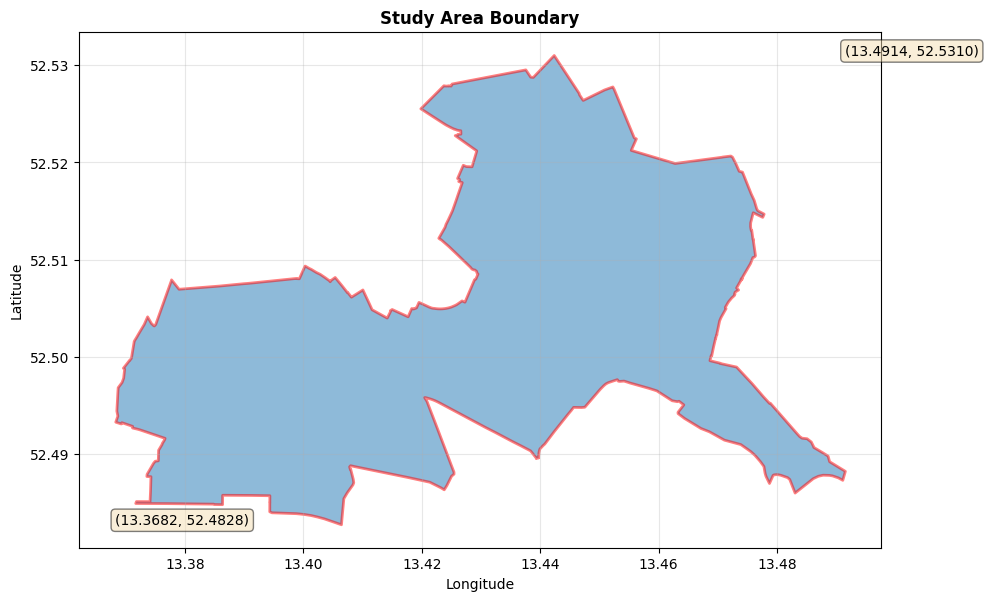

✓ Shapefile boundary visualized!


In [16]:
"""
Visualize shapefile boundary
"""

import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot shapefile
study_area.plot(ax=ax, alpha=0.5, edgecolor='red', linewidth=2)

# Add labels
ax.set_title('Study Area Boundary', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Add coordinates
bounds = study_area.bounds.iloc[0]
ax.text(bounds.minx, bounds.miny, f"({bounds.minx:.4f}, {bounds.miny:.4f})",
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(bounds.maxx, bounds.maxy, f"({bounds.maxx:.4f}, {bounds.maxy:.4f})",
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Shapefile boundary visualized!")

In [24]:
import numpy as np
from rasterio.mask import mask
import os

print("="*70)
print("CLIPPING BANDS TO STUDY AREA")
print("="*70)

# Load study area geometry
study_area = gpd.read_file(shapefile_path)

# Reference band for CRS and spatial alignment
# We'll use B08_10m.tif as the reference because it's a 10m band and seems to have the expected shape
reference_band_path = os.path.join(dirs['resampled_data'], 'B08_10m.tif')

if not os.path.exists(reference_band_path):
    print(f"ERROR: Reference band {reference_band_path} not found. Cannot proceed with clipping.")
else:
    with rasterio.open(reference_band_path) as ref_src:
        reference_crs = ref_src.crs
        # Reproject study area to the reference CRS once
        study_area_reprojected = study_area.to_crs(reference_crs)
        geometry = study_area_reprojected.geometry[0]

    print(f"\nUsing reference CRS ({reference_crs}) for clipping.")
    print(f"  Geometry type: {geometry.geom_type}")
    # Correctly format the area units to avoid TypeError
    print(f"  Area: {geometry.area:.6f} {f'{reference_crs.linear_units}²' if reference_crs.linear_units else 'degrees²'}")

    # List all resampled bands
    resampled_files = sorted([f for f in os.listdir(dirs['resampled_data']) if f.endswith('.tif')])

    print(f"\nClipping {len(resampled_files)} bands...")

    for i, input_file in enumerate(resampled_files, 1):
        input_path = os.path.join(dirs['resampled_data'], input_file)
        output_file = input_file.replace('.tif', '_clipped.tif')
        output_path = os.path.join(dirs['clipped_data'], output_file)

        print(f"[{i}/{len(resampled_files)}] Clipping {input_file}...", end=' ')

        try:
            # Read band
            with rasterio.open(input_path) as src:
                # All bands should now be compatible with the reprojected geometry's CRS
                # Clip raster to geometry using the single reprojected geometry
                data, transform = mask(src, [geometry], crop=True)
                profile = src.profile

            # Update profile
            profile.update(
                height=data.shape[1],
                width=data.shape[2],
                transform=transform,
                compress='lzw'
            )

            # Write clipped band
            with rasterio.open(output_path, 'w', **profile) as dst:
                dst.write(data)

            file_size = os.path.getsize(output_path) / 1024 / 1024
            print(f"✓ ({file_size:.1f} MB)")

        except Exception as e:
            print(f"✗ ERROR: {str(e)}")

    print("\n" + "="*70)
    print("✓ ALL BANDS CLIPPED!")
    print("="*70)

    # Verify
    clipped_files = os.listdir(dirs['clipped_data'])
    print(f"\nGenerated {len(clipped_files)} clipped files:")

    total_size = 0
    for f in sorted(clipped_files):
        file_path = os.path.join(dirs['clipped_data'], f)
        file_size = os.path.getsize(file_path) / 1024 / 1024
        total_size += file_size
        print(f"  {f}: {file_size:.1f} MB")

    print(f"\nTotal size: {total_size:.1f} MB")

CLIPPING BANDS TO STUDY AREA

Using reference CRS (EPSG:32632) for clipping.
  Geometry type: Polygon
  Area: 20395717.623112 metre²

Clipping 10 bands...
[1/10] Clipping B02_10m.tif... ✓ (0.4 MB)
[2/10] Clipping B03_10m.tif... ✓ (0.4 MB)
[3/10] Clipping B04_10m.tif... ✓ (0.4 MB)
[4/10] Clipping B05_10m.tif... ✓ (0.9 MB)
[5/10] Clipping B06_10m.tif... ✓ (0.9 MB)
[6/10] Clipping B07_10m.tif... ✓ (0.9 MB)
[7/10] Clipping B08_10m.tif... ✓ (0.5 MB)
[8/10] Clipping B11_10m.tif... ✓ (0.9 MB)
[9/10] Clipping B12_10m.tif... ✓ (0.9 MB)
[10/10] Clipping B8A_10m.tif... ✓ (0.9 MB)

✓ ALL BANDS CLIPPED!

Generated 10 clipped files:
  B02_10m_clipped.tif: 0.4 MB
  B03_10m_clipped.tif: 0.4 MB
  B04_10m_clipped.tif: 0.4 MB
  B05_10m_clipped.tif: 0.9 MB
  B06_10m_clipped.tif: 0.9 MB
  B07_10m_clipped.tif: 0.9 MB
  B08_10m_clipped.tif: 0.5 MB
  B11_10m_clipped.tif: 0.9 MB
  B12_10m_clipped.tif: 0.9 MB
  B8A_10m_clipped.tif: 0.9 MB

Total size: 6.9 MB


Clipped band info:
  Shape: (93, 141)
  Bounds: BoundingBox(left=796440.0, bottom=5823840.0, right=804900.0, top=5829420.0)
  CRS: EPSG:32632

Study area bounds:
  Min X: 13.3682, Max X: 13.4914
  Min Y: 52.4828, Max Y: 52.5310

Clipped band bounds:
  Min X: 796440.0000, Max X: 804900.0000
  Min Y: 5823840.0000, Max Y: 5829420.0000


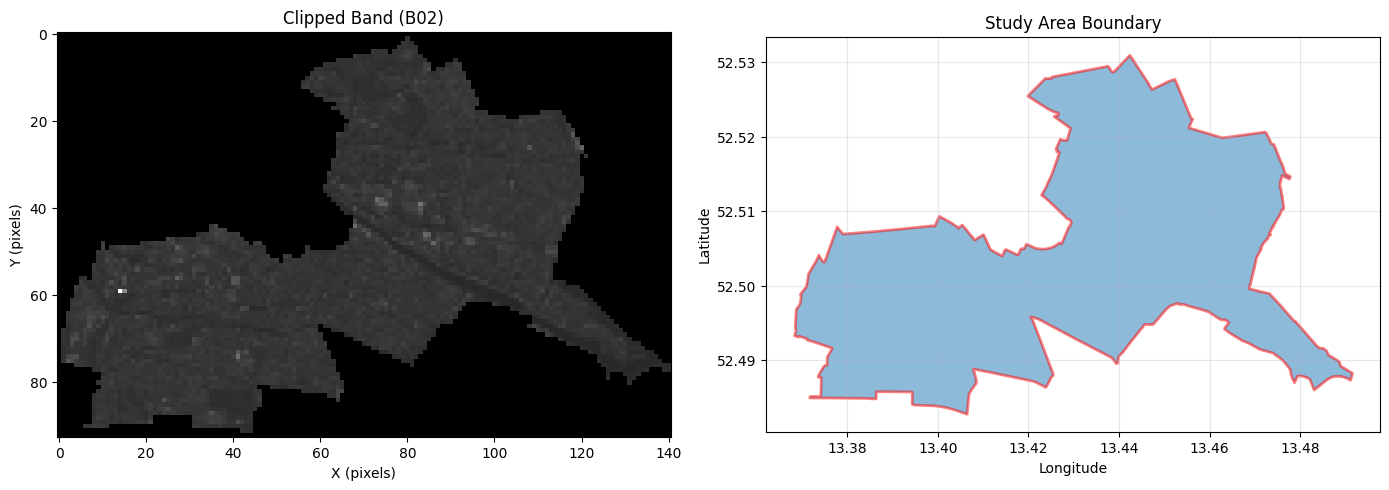


✓ Verification complete!


In [18]:
"""
Verify clipped bands match study area
"""

# Load one clipped band
clipped_band_path = os.path.join(dirs['clipped_data'], 'B02_10m_clipped.tif')

with rasterio.open(clipped_band_path) as src:
    clipped_data = src.read(1)
    clipped_bounds = src.bounds
    clipped_crs = src.crs

print(f"Clipped band info:")
print(f"  Shape: {clipped_data.shape}")
print(f"  Bounds: {clipped_bounds}")
print(f"  CRS: {clipped_crs}")

# Compare with study area
study_area = gpd.read_file(shapefile_path)
study_bounds = study_area.bounds.iloc[0]

print(f"\nStudy area bounds:")
print(f"  Min X: {study_bounds.minx:.4f}, Max X: {study_bounds.maxx:.4f}")
print(f"  Min Y: {study_bounds.miny:.4f}, Max Y: {study_bounds.maxy:.4f}")

print(f"\nClipped band bounds:")
print(f"  Min X: {clipped_bounds.left:.4f}, Max X: {clipped_bounds.right:.4f}")
print(f"  Min Y: {clipped_bounds.bottom:.4f}, Max Y: {clipped_bounds.top:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot clipped band
axes[0].imshow(clipped_data, cmap='gray')
axes[0].set_title('Clipped Band (B02)')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')

# Plot study area
study_area.plot(ax=axes[1], alpha=0.5, edgecolor='red', linewidth=2)
axes[1].set_title('Study Area Boundary')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Verification complete!")

In [26]:
import numpy as np
import rasterio
import os

"""
Extract spectral features (bands + indices)
"""

print("="*70)
print("EXTRACTING SPECTRAL FEATURES")
print("="*70)

# Load clipped bands
print("\nLoading clipped bands...")

bands_dict = {}
clipped_files = sorted([f for f in os.listdir(dirs['clipped_data']) if f.endswith('.tif')])

for clipped_file in clipped_files:
    band_name = clipped_file.split('_')[0]
    file_path = os.path.join(dirs['clipped_data'], clipped_file)

    with rasterio.open(file_path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile
        bands_dict[band_name] = data

    print(f"  ✓ Loaded {band_name}: shape={data.shape}")

# Calculate spectral indices
print("\nCalculating spectral indices...")

# NDVI
epsilon = 1e-8
ndvi = (bands_dict['B08'] - bands_dict['B04']) / (bands_dict['B08'] + bands_dict['B04'] + epsilon)
ndvi = np.clip(ndvi, -1, 1)
print(f"  ✓ NDVI: Min={np.nanmin(ndvi):.4f}, Max={np.nanmax(ndvi):.4f}, Mean={np.nanmean(ndvi):.4f}")

# NDBI
ndbi = (bands_dict['B11'] - bands_dict['B08']) / (bands_dict['B11'] + bands_dict['B08'] + epsilon)
ndbi = np.clip(ndbi, -1, 1)
print(f"  ✓ NDBI: Min={np.nanmin(ndbi):.4f}, Max={np.nanmax(ndbi):.4f}, Mean={np.nanmean(ndbi):.4f}")

# NDMI
ndmi = (bands_dict['B08'] - bands_dict['B11']) / (bands_dict['B08'] + bands_dict['B11'] + epsilon)
ndmi = np.clip(ndmi, -1, 1)
print(f"  ✓ NDMI: Min={np.nanmin(ndmi):.4f}, Max={np.nanmax(ndmi):.4f}, Mean={np.nanmean(ndmi):.4f}")

# NDSI
ndsi = (bands_dict['B03'] - bands_dict['B11']) / (bands_dict['B03'] + bands_dict['B11'] + epsilon)
ndsi = np.clip(ndsi, -1, 1)
print(f"  ✓ NDSI: Min={np.nanmin(ndsi):.4f}, Max={np.nanmax(ndsi):.4f}, Mean={np.nanmean(ndsi):.4f}")

# NDRE
ndre = (bands_dict['B08'] - bands_dict['B05']) / (bands_dict['B08'] + bands_dict['B05'] + epsilon)
ndre = np.clip(ndre, -1, 1)
print(f"  ✓ NDRE: Min={np.nanmin(ndre):.4f}, Max={np.nanmax(ndre):.4f}, Mean={np.nanmean(ndre):.4f}")

# MNDWI
mndwi = (bands_dict['B03'] - bands_dict['B12']) / (bands_dict['B03'] + bands_dict['B12'] + epsilon)
mndwi = np.clip(mndwi, -1, 1)
print(f"  ✓ MNDWI: Min={np.nanmin(mndwi):.4f}, Max={np.nanmax(mndwi):.4f}, Mean={np.nanmean(mndwi):.4f}")

print("\n✓ All spectral indices calculated!")

EXTRACTING SPECTRAL FEATURES

Loading clipped bands...
  ✓ Loaded B02: shape=(553, 841)
  ✓ Loaded B03: shape=(553, 841)
  ✓ Loaded B04: shape=(553, 841)
  ✓ Loaded B05: shape=(553, 841)
  ✓ Loaded B06: shape=(553, 841)
  ✓ Loaded B07: shape=(553, 841)
  ✓ Loaded B08: shape=(553, 841)
  ✓ Loaded B11: shape=(553, 841)
  ✓ Loaded B12: shape=(553, 841)
  ✓ Loaded B8A: shape=(553, 841)

Calculating spectral indices...
  ✓ NDVI: Min=-1.0000, Max=1.0000, Mean=0.0407
  ✓ NDBI: Min=-0.5706, Max=1.0000, Mean=0.0040
  ✓ NDMI: Min=-1.0000, Max=0.5706, Mean=-0.0040
  ✓ NDSI: Min=-0.7943, Max=0.5559, Mean=-0.0490
  ✓ NDRE: Min=-1.0000, Max=0.4548, Mean=0.0200
  ✓ MNDWI: Min=-0.6882, Max=0.6851, Mean=-0.0285

✓ All spectral indices calculated!


In [27]:
"""
Stack all features into single array
"""

print("\nStacking features...")

# Create feature list
features_list = [
    bands_dict['B02'],    # Blue
    bands_dict['B03'],    # Green
    bands_dict['B04'],    # Red
    bands_dict['B08'],    # NIR
    bands_dict['B11'],    # SWIR
    bands_dict['B12'],    # SWIR2
    ndvi,                 # NDVI
    ndbi,                 # NDBI
    ndmi,                 # NDMI
    ndsi,                 # NDSI
    ndre,                 # NDRE
    mndwi,                # MNDWI
]

# Stack into single array
feature_stack = np.stack(features_list, axis=0)

print(f"✓ Feature stack created!")
print(f"  Shape: {feature_stack.shape}")
print(f"  Dimensions: {feature_stack.shape[0]} features × {feature_stack.shape[1]} rows × {feature_stack.shape[2]} columns")
print(f"  Memory size: {feature_stack.nbytes / 1024 / 1024:.2f} MB")

# Save feature stack
feature_stack_path = os.path.join(dirs['spectral_features'], 'features_stacked.npy')
np.save(feature_stack_path, feature_stack)
print(f"\n✓ Feature stack saved: {feature_stack_path}")


Stacking features...
✓ Feature stack created!
  Shape: (12, 553, 841)
  Dimensions: 12 features × 553 rows × 841 columns
  Memory size: 21.29 MB

✓ Feature stack saved: /content/drive/My Drive/WorkflowB/spectral_features/features_stacked.npy
